# Bootstrap samples and Random Forests

# Objectives

* Understand bootstrap samples of data.
* Learn how to use *probabilistic* random forest classifiers in sklearn

* See tradeoffs in RFs as a function of different hyperparameters
* * max_features : Number of features considered at each decision node when finding the best split
* * max_depth
* * min_samples_per_leaf

We'll reuse the same examples from our experience with Logistic Regression and kNN to provide some common ground

# Outline

* [Part 1: Bootstrap samples](#part1)
* [Part 2: Binary classification with Random Forests on 1-dim. toy example](#part2)
* [Part 3: Visualizing decision boundaries of Decision Trees on 2-dim. features](#part3)
* [Part 4: Implementing Gradient Boosting on simple data](#part4)

# Takeaways for Part 1
 
* The bootstrap is a simple procedure for drawing other datasets that are "similar" to your original (plausibly from same empirical distribution)
* The limiting probability that each example is included in a bootstrap sample has a nice closed form (related to $e$)

# Takeaways for Part 2-3

* Random forests offer smoother, more flexible decision boundaries than a single decision tree
* Adding more trees will usually strictly improve the performance (albeit at increased computation cost), until you saturate at some plateau
* Adjusting hyperparameters like max_depth can help manage overfitting even in RandomForests

In [1]:
import numpy as np

In [2]:
import sklearn.tree
import sklearn.ensemble


In [3]:
# import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', font_scale=1.25, style='whitegrid')

# Part 1: The Bootstrap

Credit to ISL textbook Sec. 5.4 for inspiring this content.

Recall that a bootstrap sample $\mathcal{S}$ for a dataset $\{x_n\}_{n=1}^N$ of size $N$ is obtained, by

```
INPUT: x[n] for n in 1, 2, ... N

initialize empty set S
for n in 1, 2, ... N:
    i <- draw_int_from_uniform( low=1, high=N)
    add x[i] to S
```

### Simple for loop implementation of bootstrap

In [6]:
def draw_bootstrap_dataset_forloop(x_N, random_state=0):
    if isinstance(random_state, int):
        random_state = np.random.RandomState(int(random_state))

    N = x_N.shape[0]
    xboot_N = np.zeros(x_N.shape) # create empty array of desired size (same as input)
    for n in range(N):
        i = random_state.randint(low=0, high=N)
        xboot_N[n] = x_N[i]
    return xboot_N

### Demonstration: Show 10 different bootstrap samples of an N=3 dataset

In [4]:
xorig_N = np.asarray([0, 1, 2])

In [7]:
for i in range(10):
    xboot_N = draw_bootstrap_dataset_forloop(xorig_N, random_state=i) # be sure to use a different seed for each sample
    print("sample %d:\n    %s" % (i, str(xboot_N)))

sample 0:
    [0. 1. 0.]
sample 1:
    [1. 0. 0.]
sample 2:
    [0. 1. 0.]
sample 3:
    [2. 0. 1.]
sample 4:
    [2. 2. 1.]
sample 5:
    [2. 1. 2.]
sample 6:
    [2. 1. 0.]
sample 7:
    [0. 1. 2.]
sample 8:
    [0. 1. 1.]
sample 9:
    [2. 0. 2.]


### Demo: We can also draw samples when each example has multiple features

Create a dataset with N rows and 2 columns (e.g. each example has a feature vector of size F=2)

In [8]:
xorig_N2 = np.asarray([[1, 1], [2, 2], [3, 3]])
print(xorig_N2)

[[1 1]
 [2 2]
 [3 3]]


Here is one bootstrap sample!

In [9]:
draw_bootstrap_dataset_forloop(xorig_N2)

array([[1., 1.],
       [2., 2.],
       [1., 1.]])

### Exercise 1a: Show 10 different bootstrap samples for dataset with N=3 and F =2

In [11]:
for i in range(10):
    # draw bootstrap sample of data in array xorig_N2 with seed i
    xboot_N2 = draw_bootstrap_dataset_forloop(xorig_N2, random_state=i)
    print("sample %d:\n    %s" % (i, str(xboot_N2)))

sample 0:
    [[1. 1.]
 [2. 2.]
 [1. 1.]]
sample 1:
    [[2. 2.]
 [1. 1.]
 [1. 1.]]
sample 2:
    [[1. 1.]
 [2. 2.]
 [1. 1.]]
sample 3:
    [[3. 3.]
 [1. 1.]
 [2. 2.]]
sample 4:
    [[3. 3.]
 [3. 3.]
 [2. 2.]]
sample 5:
    [[3. 3.]
 [2. 2.]
 [3. 3.]]
sample 6:
    [[3. 3.]
 [2. 2.]
 [1. 1.]]
sample 7:
    [[1. 1.]
 [2. 2.]
 [3. 3.]]
sample 8:
    [[1. 1.]
 [2. 2.]
 [2. 2.]]
sample 9:
    [[3. 3.]
 [1. 1.]
 [3. 3.]]


### Exercise 1c: Some math problems

- What is the probability that when N=1, your bootstrap sample does not contain the first item in original dataset?
- What is the probability that when N=2, your bootstrap sample does not contain the first item in original dataset?
- What is the probability that when N=3, your bootstrap sample does not contain the first item in original dataset?
- What is the probability that when N=5, your bootstrap sample does not contain the first item in original dataset?

- 0
- 1/2 * 1/2
- 2/3 * 2/3 * 2/3
- 4/5 * 4/5 * 4/5 * 4/5

### Discussion 1d: Argue why the following is true:

Given a large dataset of size $N$, the probability your bootstrap sample does NOT contain any single item $x_i$ in the original dataset is:

$$
p( x_i \notin S ) = \left(1 - \frac{1}{N} \right)^N
$$


Prob of x_i not being selected for a single "drawing" is 1 - 1/N. N independent selections gives the equation above.

### Exercise 1e: Create a plot showing this probability from 1d as $N$ varies from 100 to 50000 (step by 100)

What is the limiting value of this expression? Can you express it in terms of the natural number $e$?

In [12]:
N_grid = np.arange(100, 50000, 100)
p_grid = (1-1/N_grid)**N_grid # fill entries of p using formula above in 1d

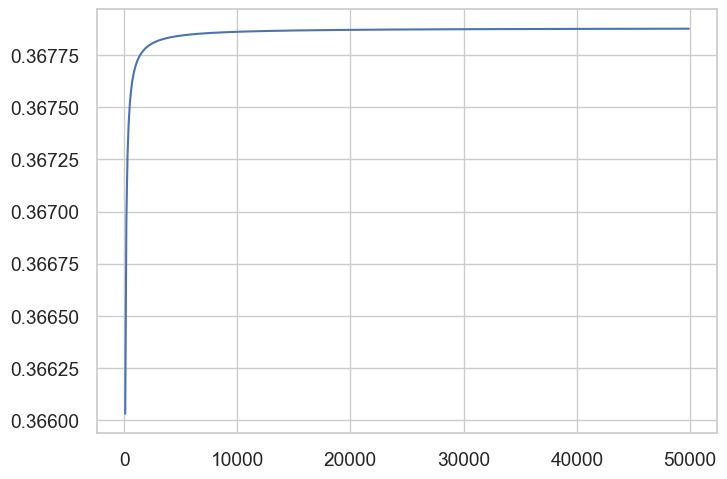

In [13]:
plt.plot(N_grid, p_grid)

As it turns out, the value it is converging to is $\frac{1}{e}$! You may have seen in a class before that
$$\lim_{N \to \infty} \bigg(1 + \frac{1}{N}\bigg)^N = e$$
But it's also true that
$$\lim_{N \to \infty} \bigg(1 - \frac{1}{N}\bigg)^N = \frac{1}{e}$$
So as our dataset gets large, we'll have on average $\approx 63\%$ of models in the ensemble that have not seen a particular data point.

### Vectorized implementation of bootstrap

This is a much faster implementation (no for loops!)

But it is the *same* as the one above in terms of the distribution it samples from.

In [ ]:
def draw_bootstrap_dataset_vectorized(x_N, random_state=0):
    if isinstance(random_state, int):
        random_state = np.random.RandomState(int(random_state))
    N = x_N.shape[0]
    row_ids = random_state.choice(np.arange(N), size=N, replace=True)
    return x_N[row_ids].copy()

# Setup for Part 2

### Setting up a simple classification task with 1-dim features

Let's think about a classification task where:

Each input is just scalar $x$ between -1 and +1.

The "true" label assignment function is as follows:

$$
y(x) = \begin{cases} 
1 & \text{if} ~ x > 0 \\
0 & \text{otherwise}
\end{cases}
$$

The true labeling process also has some noise: after assigning a label with the above function, each example has a ~15% chance of the opposite label. 

This noise makes our classification interesting. The "best case" error rate is about ~15%.

### Make training set for 1-dim. toy example

In [14]:
# We generated this training set for you.

N = 12

x_tr_N = np.asarray([
    -0.975, -0.825, -0.603, -0.378, -0.284, -0.102,
     0.169,  0.311,  0.431,  0.663,  0.795,  0.976])
x_tr_N1 = x_tr_N.reshape((N,1)) # need an (N,1) shaped array for later use with sklearn

y_tr_N = np.asarray([0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1])

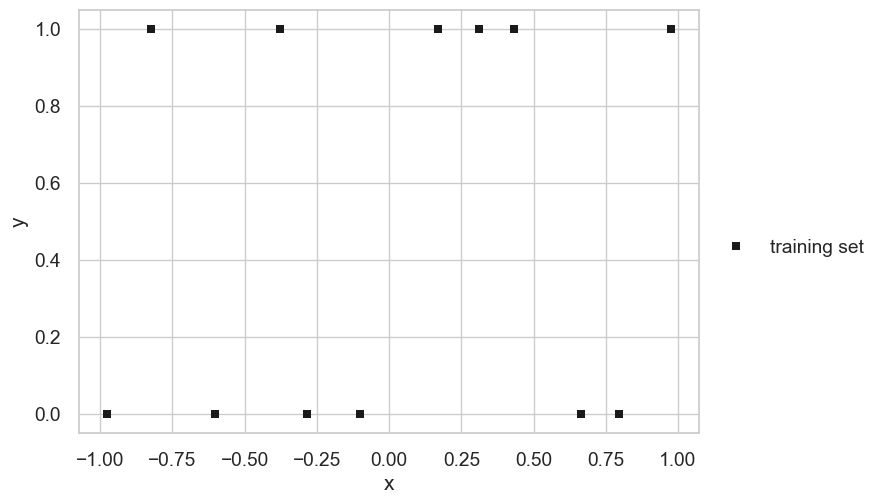

In [15]:
plt.plot(x_tr_N, y_tr_N, 'ks', label='training set');
plt.xlabel('x');
plt.ylabel('y');
plt.legend(bbox_to_anchor=(1.0, 0.5));

# Part 2: Train random forest for F=1 data

See the docs for RandomForestClassifier here: <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html>


In [16]:
tree = sklearn.tree.DecisionTreeClassifier(max_depth=6)
tree.fit(x_tr_N1, y_tr_N);

### Train a forest with *5* trees

Each tree will use a *different* bootstrap sample of your dataset

In [17]:
forest5 = sklearn.ensemble.RandomForestClassifier(bootstrap=True, max_depth=6, n_estimators=5);
forest5.fit(x_tr_N1, y_tr_N);

### Train a forest with *100* trees

Each tree will use a *different* bootstrap sample of your dataset

In [18]:
forest100 = sklearn.ensemble.RandomForestClassifier(bootstrap=True, max_depth=6, n_estimators=100);
forest100.fit(x_tr_N1, y_tr_N);

### Make predictions using our tree using `predict_proba`

Remember, `predict_proba()` returns the probabilities of ALL possible labels: 0 and 1

There will be two columns, one for each label.

The first column is for the class corresponding to binary label 0.
The second column is for the class corresponding to binary label 1.

## Setup : Prepare for a plot over dense grid of inputs

In [19]:
# Create dense grid of L input examples from -1.5 to 1.5
# so we can better understand the learned predictions
L = 101
dense_x_L1 = np.linspace(-1.5, 1.5, L).reshape((L,1))

## Plot: predicted probabilities vs. feature value

We can see that the predicted probabilities from Decision Trees are *piecewise constant*.

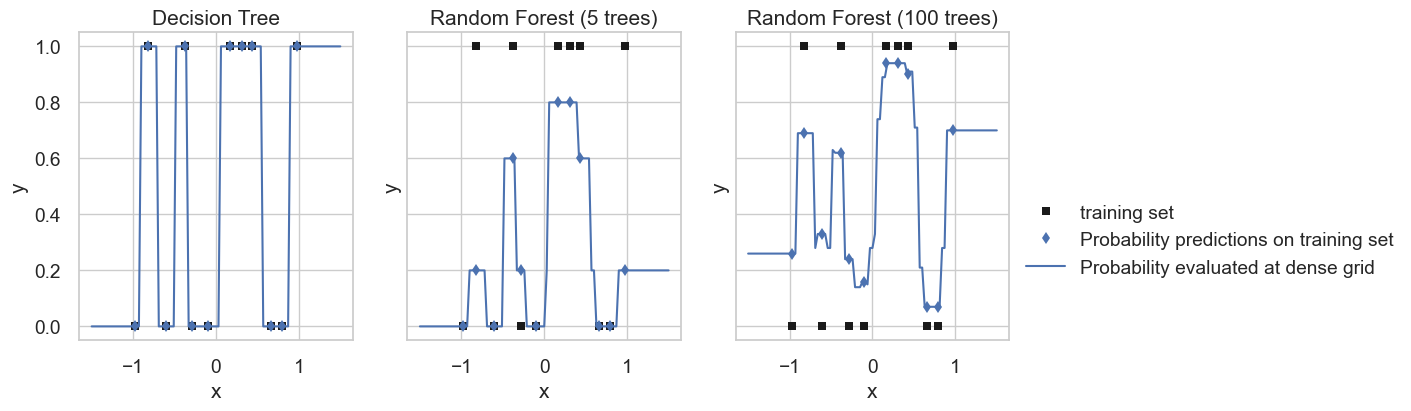

In [20]:
fig, ax_grid = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(12,4));

for mm, (method_name, classifier) in enumerate([
            ('Decision Tree', tree),
            ('Random Forest (5 trees)', forest5),
            ('Random Forest (100 trees)', forest100),
            ]):
    plt.sca(ax_grid[mm])
    plt.plot(x_tr_N, y_tr_N, 'ks', label='training set');

    yproba1_N = classifier.predict_proba(x_tr_N1)[:,1]
    plt.plot(x_tr_N, yproba1_N, 'bd', label='Probability predictions on training set');

    # Apply our trained tree to make predictions along this grid
    # Uses the syntax [:,1] to access the column with index 1 (so we only get the probas for positive class)
    yproba1_dense_L = classifier.predict_proba(dense_x_L1)[:,1]
    plt.plot(dense_x_L1, yproba1_dense_L, 'b-', label='Probability evaluated at dense grid')

    plt.xlabel('x');
    plt.ylabel('y');
    if mm == ax_grid.size - 1:
        plt.legend(bbox_to_anchor=(1.0, 0.5));
    plt.title("%s" % method_name);

## Discussion 2a: What value does the predicted probability take at x=1.5, as we include more and more trees? Can you argue about why it takes this value?

* Hint 1: What is the probability that any single bootstrap sample includes the data point with largest $x$ value?
* Hint 2: Given *this* training set, what will a single decision tree tend to predict if it includes this point, vs. if it doesnt?

$x = 1.5$ is at the extremity of the training data set. Because each tree is very deep here (note that this is not usually how you train a random forest; you want each tree to have limited flexibility) each tree will fit the training data very tightly. If each tree separates the training data into separate regions, one for each point, than the extremity will be classified as whatever the largest value in the bootstrap sample is. Here, the largest value is 0 with probability $(1-1/12)^{12}\approx 0.35$ (because the largest input is not sampled, so we end up with a largest input whose $y$ value is 0), and the value is 1 with probability $1-0.35$ (the largest input is included). The average of these votes will yield a $\hat{p} \approx 2/3$, which matches what we see above.

## Discussion 2b: What do you think would happen if we used 1000 trees or 1 million trees?

Because each tree is very flexible, we'll converge to a more smoothly-transitioning function, but it will still extremely overfit the data. It'll never become perfectly smooth, because there are only 12 data points and so there is a very limited set of locations we can put splits, given we always split in the middle. In the original data set, there are only 11 possible locations for splits. In the bootstrap samples there are more, because we can take the midpoint of 2 non-adjacent data points when the point(s) between them are removed in the bootstrap process, but there's still a finite, and relatively small, number of possible splits.

# Setup for Part 3

### Define simple dataset of points in 2D space

Don't worry about the details of this setup.
Just try to understand the plots below.

In [21]:
def create_2d_dataset(N=100, noise_stddev=0.25, random_state=0):
    random_state = np.random.RandomState(int(random_state))

    mA_2 = np.asarray([1, 0])
    covA_22 = np.square(noise_stddev) * np.eye(2)
    
    mB_2 = np.asarray([0, 0])
    covB_22 = np.square(noise_stddev) * np.eye(2)

    mC_2 = np.asarray([0, 1])
    covC_22 = np.square(noise_stddev) * np.eye(2)

    # Draw data from 3 "Gaussian" blobs
    xA_N2 = random_state.multivariate_normal(mA_2, covA_22, size=N)
    xB_N2 = random_state.multivariate_normal(mB_2, covB_22, size=N)
    xC_N2 = random_state.multivariate_normal(mC_2, covC_22, size=N)

    x_N2 = np.vstack([xA_N2, xB_N2, xC_N2])
    y_N = np.hstack([np.ones(xA_N2.shape[0]), np.zeros(xB_N2.shape[0]), np.ones(xC_N2.shape[0])])
    
    return x_N2, y_N

## Create training and validation datasets with 100 points per class

In [22]:
x_tr_N2, y_tr_N = create_2d_dataset(N=100, random_state=101);

In [23]:
x_va_N2, y_va_N = create_2d_dataset(N=100, random_state=202);

### Define function to plot data as scatterpoints in 2d

In [24]:
def plot_pretty_data_colored_by_labels(x_N2, y_N):
    plt.plot(x_N2[y_N==0,0], x_N2[y_N==0,1], color='r', marker='x', linestyle='', markersize=5, mew=2, label='y=0');
    plt.plot(x_N2[y_N==1,0], x_N2[y_N==1,1], color='b', marker='+', linestyle='', markersize=8, mew=2, label='y=1');

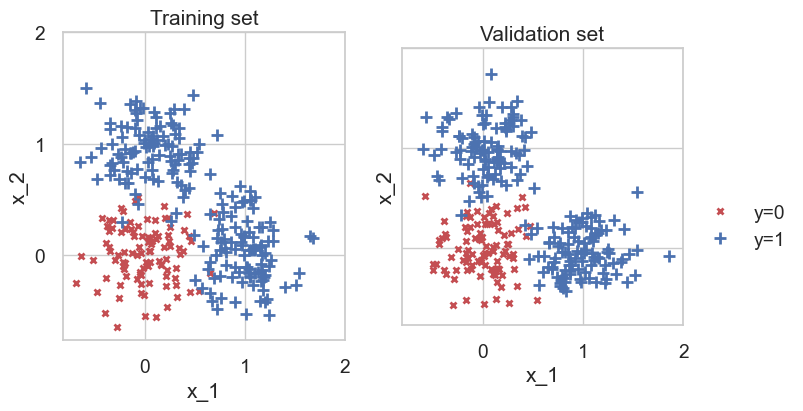

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4), sharex=True, sharey=True)

plt.sca(ax[0])
plot_pretty_data_colored_by_labels(x_tr_N2, y_tr_N);
plt.title("Training set");
plt.xlabel('x_1');
plt.ylabel('x_2');

plt.sca(ax[1])
plot_pretty_data_colored_by_labels(x_va_N2, y_va_N);
plt.title("Validation set");
plt.xlabel('x_1');
plt.ylabel('x_2');

plt.legend(bbox_to_anchor=(1.0, 0.5));
plt.gca().set_aspect(1.0);
plt.xticks([0, 1, 2]);
plt.yticks([0, 1, 2]);


### Define function to make pretty plots of predicted probability color fields

You don't need to understand this in detail. Just a utility function.

In [26]:
def plot_pretty_probabilities_for_clf(
        clf,
        do_show_colorbar=False,
        x1_ticks=np.asarray([0, 2, 4]),
        x2_ticks=np.asarray([0, 2, 4]),
        c_levels=np.linspace(0, 1, 100),
        c_ticks=np.asarray([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        x1_grid=np.linspace(-1, 2.3, 100),
        x2_grid=np.linspace(-1, 2.3, 100)):
    cur_ax = plt.gca()
    
    G = x1_grid.size
    H = x2_grid.size
    
    # Get regular grid of G x H points, where each point is an (x1, x2) location
    x1_GH, x2_GH = np.meshgrid(x1_grid, x2_grid)
    
    # Combine the x1 and x2 values into one array
    # Flattened into M = G x H rows
    # Each row of x_M2 is a 2D vector [x_m1, x_m2]
    x_M2 = np.hstack([x1_GH.flatten()[:,np.newaxis], x2_GH.flatten()[:,np.newaxis]])
    
    # Predict proba for each point in the flattened grid
    yproba1_M = clf.predict_proba(x_M2)[:,1]
    
    # Reshape the M probas into the GxH 2D field
    yproba1_GH = np.reshape(yproba1_M, x1_GH.shape)
    
    cmap = plt.cm.RdYlBu
    my_contourf_h = plt.contourf(x1_GH, x2_GH, yproba1_GH, levels=c_levels, vmin=0, vmax=1.0, cmap=cmap)
    
    plt.xticks(x1_ticks, x1_ticks);
    plt.yticks(x2_ticks, x2_ticks);
    
    if do_show_colorbar:
        left, bottom, width, height = plt.gca().get_position().bounds
        cax = plt.gcf().add_axes([left+1.1*width, bottom, 0.03, height])
        plt.colorbar(my_contourf_h, orientation='vertical', cax=cax, ticks=c_ticks);
        plt.sca(cur_ax);

# Part 3: Visualization of RandomForest predictions as we vary max_depth

Generally, max depth is one of the key hyperparameters that controls model complexity of decision trees.

What about for random forests? Do the models change visibly?

## From last time: DecisionTree learned decision boundaries 

Looking at the learned classification probabilities as a function of the features

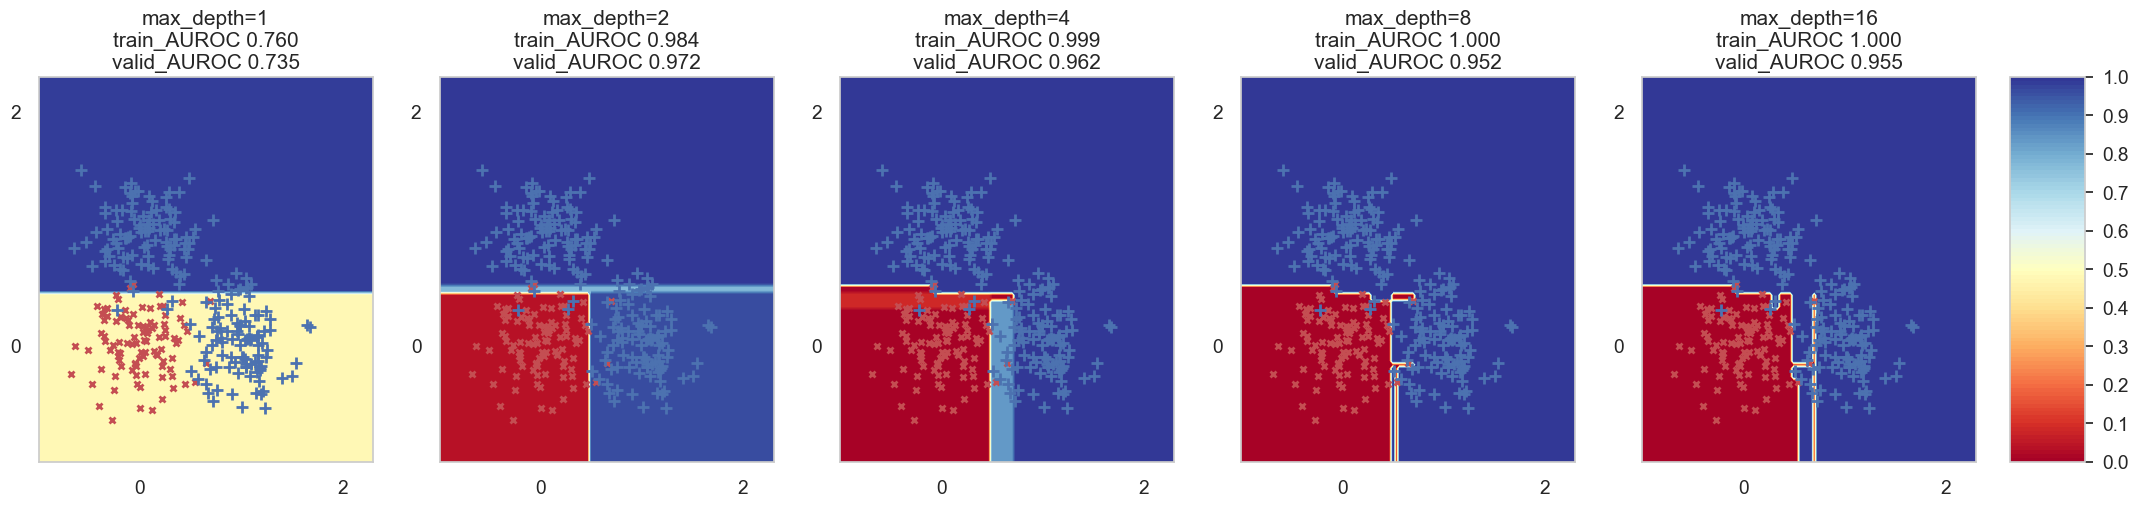

In [27]:
max_depth_grid = [1, 2, 4, 8, 16]

trees_by_depth = dict()

ncols = len(max_depth_grid)
fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, max_depth in enumerate(max_depth_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(x_tr_N2, y_tr_N)

    plot_pretty_probabilities_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_tr_N2, y_tr_N);
    
    tr_auroc = sklearn.metrics.roc_auc_score(y_tr_N, clf.predict_proba(x_tr_N2)[:,1])
    va_auroc = sklearn.metrics.roc_auc_score(y_va_N, clf.predict_proba(x_va_N2)[:,1])
    
    plt.title("max_depth=%d\ntrain_AUROC %.3f\nvalid_AUROC %.3f" % (max_depth, tr_auroc, va_auroc))
    
    # Store for later
    trees_by_depth[max_depth] = clf

## New today: Random forest with 25 trees and max_features=1

Looking at the learned classification probabilities as a function of the features

Compare with the above.

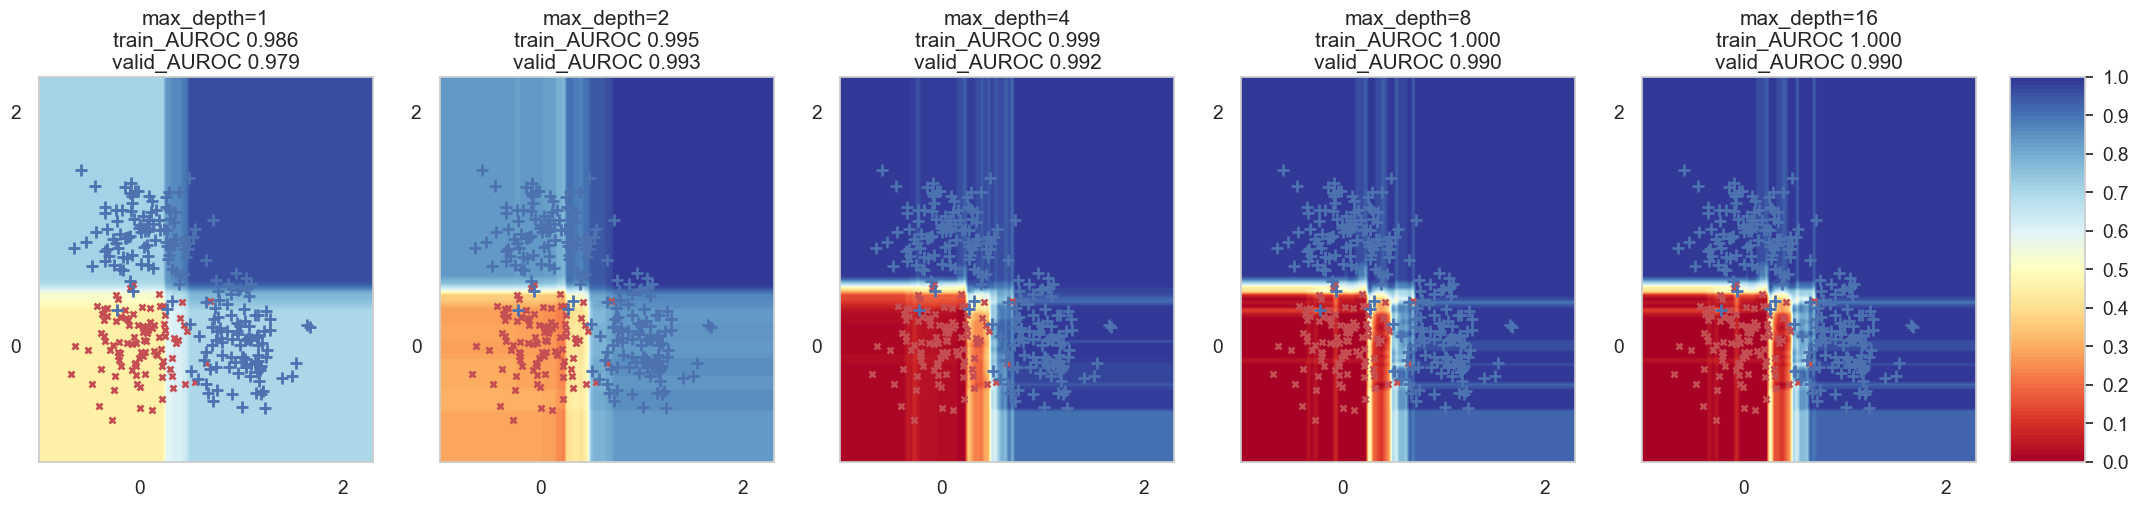

In [28]:
max_depth_grid = [1, 2, 4, 8, 16]

trees_by_depth = dict()

ncols = len(max_depth_grid)
fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, max_depth in enumerate(max_depth_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.ensemble.RandomForestClassifier(
        max_depth=max_depth, n_estimators=25, bootstrap=True, max_features=1, random_state=101)
    clf.fit(x_tr_N2, y_tr_N)

    plot_pretty_probabilities_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_tr_N2, y_tr_N);
    
    tr_auroc = sklearn.metrics.roc_auc_score(y_tr_N, clf.predict_proba(x_tr_N2)[:,1])
    va_auroc = sklearn.metrics.roc_auc_score(y_va_N, clf.predict_proba(x_va_N2)[:,1])
    
    plt.title("max_depth=%d\ntrain_AUROC %.3f\nvalid_AUROC %.3f" % (max_depth, tr_auroc, va_auroc))


## Discussion 2b: What are the biggest changes in the qualitative appearance of the predicted probabilities for this RandomForest compared to the DecisionTree above? 

* Are there changes only for some depths?

Even when max depth is 8 or 16, the random forest's boundary is much less jagged than the decision tree above. There is jaggedness in the probabilities, but that jaggedness corresponds to probabilities bouncing between e.g. 1 and 0.8, or 0 and 0.2, instead of the decision tree which had crazy jumps between probability of 0 and 1 in regions that looked clearly overfit. 

This happens because the random forest is averaging over many noisy trees. When we perform this averaging, the effect of each individual tree's jaggedness is washed away by the majority vote, and we get something smoother (still not completely smooth, but much better).

## Discussion 2c: What depth would you pick if you wanted to generalize well to new data? (Again you can use the AUROC on validation). Does it seem as sensitive as it does in the DecisionTreeClassifier? 

The best classifier is still the one with max_depth=2, but its performance is better than the depth 2 tree and the decay in AUROC performance as we increase max depth is much slower than the decay for the decision tree (e.g. max_depth=4 has a validation AUROC of 0.992, just below the 0.993 for max_depth=2). This model seems much less sensitive to depth than the decision tree classifier, because of the variance-reduction property in the averaging in the ensemble.

# Part 4: Gradient Boosting

Finally, let's look at a simple gradient boosting model to better understand what it's actually doing. 

We'll first generate some simple data for it to try to learn. 

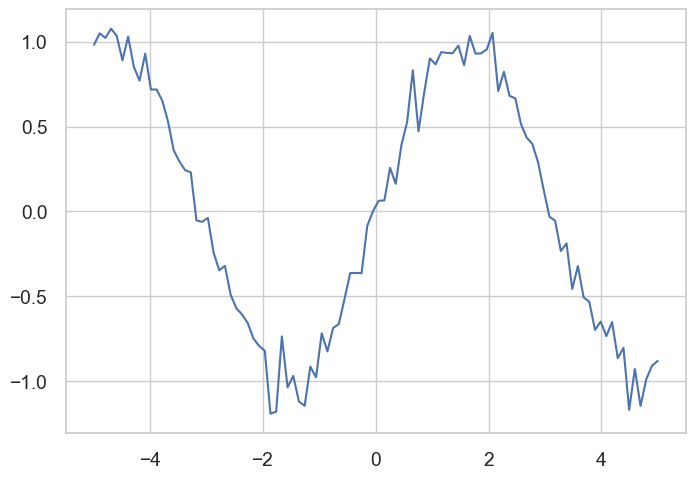

In [30]:
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
plt.plot(X, y)
plt.show()

Now we'll implement a simple gradient boosted tree setup. Each iteration, we we train a tree on the residuals from the previous iteration, and combine them using a learning rate to slowly improve the final prediction. 

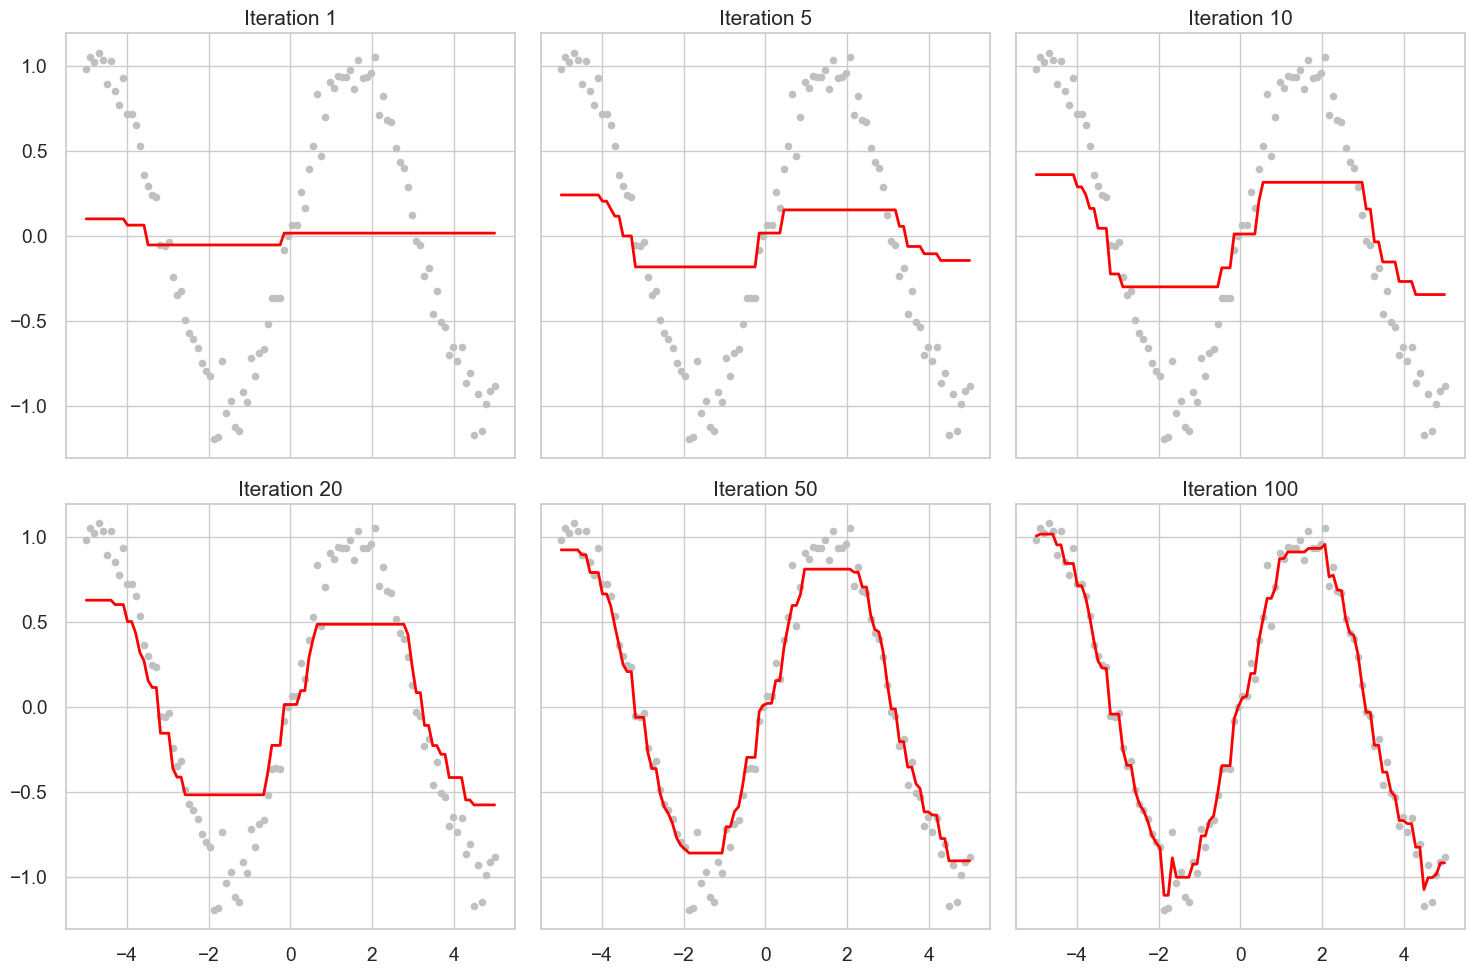

In [31]:
n_estimators = 100
learning_rate = 0.1 # Fairly high learning rate
milestones = [1, 5, 10, 20, 50, 100] # Iterations to plot the prediction so far

# f_current keeps track of our total current ensemble prediction
# Instead of making a whole tree, we know that a constant predictor is going 
# to predict the mean of our data, so we can just start with that. 
f_current = np.full(y.shape, np.mean(y))
residuals_all = []
trees = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
plot_idx = 0

# Boosting Loop
for i in range(1, n_estimators + 1):
    # Loss = 1/2 (y - f)^2  =>  -dL/df = (y - f)
    residuals = y - f_current
    residuals_all.append(residuals.copy()) # Store to plot later
    
    # Fit tree "stump" to residuals
    tree = sklearn.tree.DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residuals)
    
    # Update f_current with the new tree*learning rate 
    # to get the new ensemble prediction
    f_current += learning_rate * tree.predict(X)
    trees.append(tree)
    
    # Plot the current prediction at milestones
    if i in milestones:
        ax = axes[plot_idx]
        ax.scatter(X, y, color='silver', s=20, label='Data')
        ax.plot(X, f_current, color='red', linewidth=2, label=f'm={i}')
        ax.set_title(f"Iteration {i}")
        plot_idx += 1

plt.tight_layout()
plt.show()

Try re-running the above code but changing the tree max depth. What happens to the trees over time?

Let's also take a look at what some of the actual tree are predicting. Do the patterns below make sense?

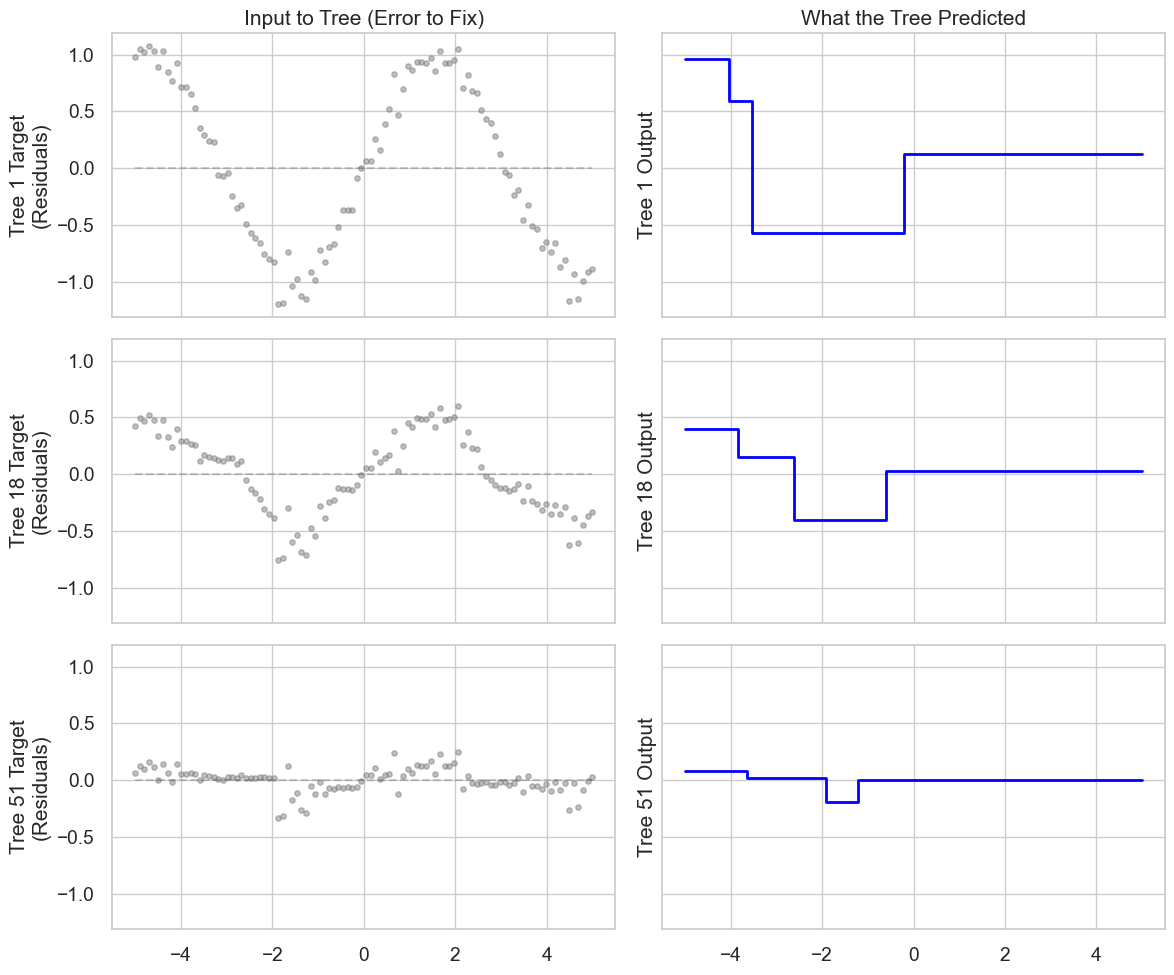

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)

target_indices = [0, 17, 50] 

for row, idx in enumerate(target_indices):

    current_residuals = residuals_all[idx]
    current_tree_pred = trees[idx].predict(X)
    
    # Plotting the Goal (Residuals)
    axes[row, 0].scatter(X, current_residuals, color='gray', s=15, alpha=0.5)
    axes[row, 0].plot(X, np.zeros_like(X), 'k--', alpha=0.2)
    axes[row, 0].set_ylabel(f"Tree {idx+1} Target\n(Residuals)")
    if row == 0: axes[row, 0].set_title("Input to Tree (Error to Fix)")
    
    # Plotting the Model (The Tree's Output)
    axes[row, 1].step(X, current_tree_pred, color='blue', where='mid', linewidth=2)
    axes[row, 1].set_ylabel(f"Tree {idx+1} Output")
    if row == 0: axes[row, 1].set_title("What the Tree Predicted")

plt.tight_layout()
plt.show()

The pattern does make sense! Each tree is fitting some of the errors leftover by the previous trees, so the residuals on the left are getting smaller and smaller across iteration. In the beginning, the piecewise constant structure of the tree cannot effectively fit the smoothly-changing function, but by slowly chipping away at the residuals we are converging to a very accurate model. Eventually, e.g. for tree 51, the vast majority of the meaningful trends in the data have been fit by precious trees and most of what remains is the inherent randomness/noise in the data. Fitting another 50 trees causes us to try to fit those parts of the residuals, showing clear signs of overfitting.